<a href="https://colab.research.google.com/github/Anthonerp/HoangIntroToMachineLearning/blob/main/Homework_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1 — Installs (run once)
!pip -q install requests textblob wordcloud imageio nltk

In [2]:
# Cell 2 — NLTK downloads
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab', quiet=True)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [3]:
# Cell 3 — Imports
import re
import string
import requests
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from textblob import TextBlob

from wordcloud import WordCloud
import imageio

In [4]:
# Cell 4 — Download Hamlet from Project Gutenberg
target_url = "https://www.gutenberg.org/files/2265/2265-0.txt"
response = requests.get(target_url)
response.raise_for_status()
data = response.text

print("Characters:", len(data))
print(data[:500])

Characters: 171696
*** START OF THE PROJECT GUTENBERG EBOOK 2265 ***


Executive Director's Notes:

In addition to the notes below, and so you will *NOT* think all
the spelling errors introduced by the printers of the time have
been corrected, here are the first few lines of Hamlet, as they
are presented herein:

  Barnardo. Who's there?
  Fran. Nay answer me: Stand & vnfold
your selfe

   Bar. Long liue the King

       *       *       *       *       *

As I understand it, the printers often ra


In [5]:
# Cell 5 — Strip Gutenberg header/footer
# Gutenberg texts include a license header/footer; removing it helps avoid skew.
start_marker = "*** START OF THE PROJECT GUTENBERG EBOOK HAMLET ***"
end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK HAMLET ***"

start = data.find(start_marker)
end = data.find(end_marker)

if start != -1 and end != -1:
    data_clean = data[start + len(start_marker):end]
else:
    # Fallback: if markers change, just use full text
    data_clean = data

print("Characters after strip:", len(data_clean))
print(data_clean[:500])

Characters after strip: 171696
*** START OF THE PROJECT GUTENBERG EBOOK 2265 ***


Executive Director's Notes:

In addition to the notes below, and so you will *NOT* think all
the spelling errors introduced by the printers of the time have
been corrected, here are the first few lines of Hamlet, as they
are presented herein:

  Barnardo. Who's there?
  Fran. Nay answer me: Stand & vnfold
your selfe

   Bar. Long liue the King

       *       *       *       *       *

As I understand it, the printers often ra


In [6]:
# Cell 6 — TextBlob
blob = TextBlob(data_clean)
print("Blob created. Sample words:", blob.words[:20])

Blob created. Sample words: ['START', 'OF', 'THE', 'PROJECT', 'GUTENBERG', 'EBOOK', '2265', 'Executive', 'Director', "'s", 'Notes', 'In', 'addition', 'to', 'the', 'notes', 'below', 'and', 'so', 'you']


In [7]:
# Cell 7 — Clean, tokenize, remove stopwords, lemmatize
lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words("english"))
# Add a few extra common tokens seen in plays / Gutenberg formatting
stop_words.update({
    "’", "''", "``", "thou", "thee", "thy", "thine",
    "ha", "ham", "hor", "pol", "laer", "oph", "claud", "gertrude",
    "act", "scene"
})

# Normalize text
text = data_clean.lower()

# Remove stage directions like [Enter ...] if present, and non-letter characters
text = re.sub(r"\[.*?\]", " ", text)

# Tokenize
tokens = word_tokenize(text)

# Filter tokens: alphabetic only, not stopwords, length > 1, lemmatize
words = []
for t in tokens:
    if t.isalpha() and t not in stop_words and len(t) > 1:
        words.append(lemmatizer.lemmatize(t))

print("Total cleaned words:", len(words))
print("Sample:", words[:30])

Total cleaned words: 14810
Sample: ['start', 'project', 'gutenberg', 'ebook', 'executive', 'director', 'note', 'addition', 'note', 'think', 'spelling', 'error', 'introduced', 'printer', 'time', 'corrected', 'first', 'line', 'hamlet', 'presented', 'herein', 'barnardo', 'fran', 'nay', 'answer', 'stand', 'vnfold', 'selfe', 'bar', 'long']


In [8]:
# Cell 8 — Word frequencies + Top 20
freq = Counter(words)
top20 = freq.most_common(20)

top20

[('lord', 216),
 ('king', 181),
 ('haue', 175),
 ('come', 129),
 ('hamlet', 107),
 ('let', 107),
 ('shall', 107),
 ('good', 98),
 ('enter', 85),
 ('like', 81),
 ('oh', 81),
 ('father', 71),
 ('well', 70),
 ('make', 70),
 ('may', 69),
 ('know', 69),
 ('would', 68),
 ('selfe', 67),
 ('sir', 65),
 ('loue', 65)]

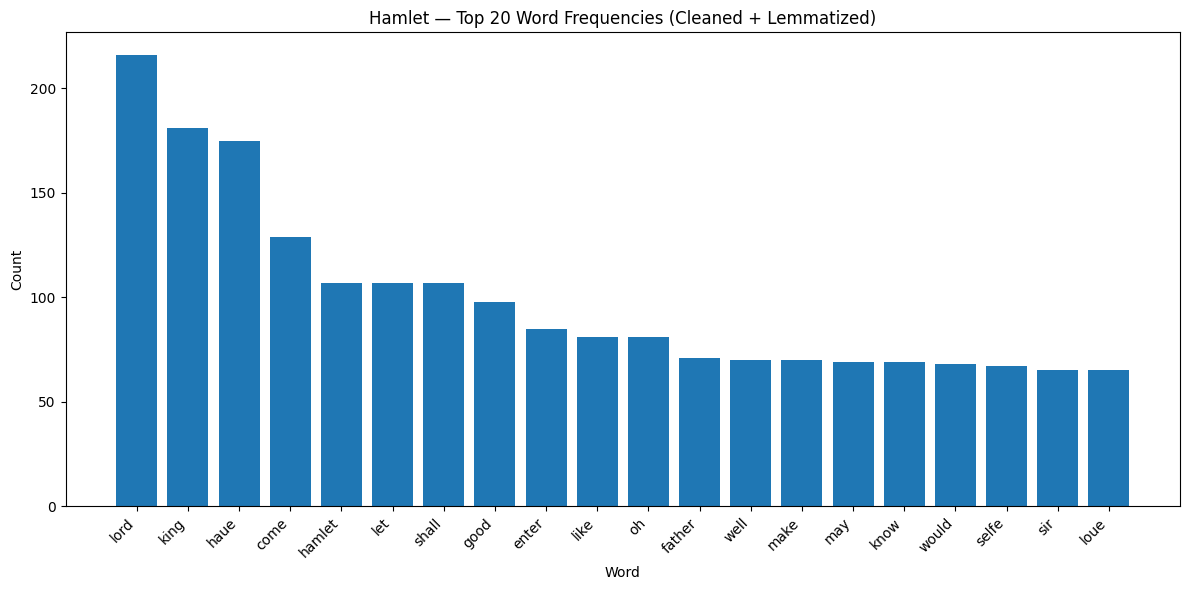

In [9]:
# Cell 9 — Top-20 bar chart
labels = [w for w, c in top20]
counts = [c for w, c in top20]

plt.figure(figsize=(12, 6))
plt.bar(labels, counts)
plt.xticks(rotation=45, ha="right")
plt.title("Hamlet — Top 20 Word Frequencies (Cleaned + Lemmatized)")
plt.xlabel("Word")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [10]:
# Cell 10 — Load the oval mask image
image_file = "https://media.cheggcdn.com/media/216/21621ee5-e80f-47f3-9145-513f2229b390/phploeBuh.png"
mask_image = imageio.v3.imread(image_file)

mask_image.shape, mask_image.dtype

((592, 1024, 3), dtype('uint8'))

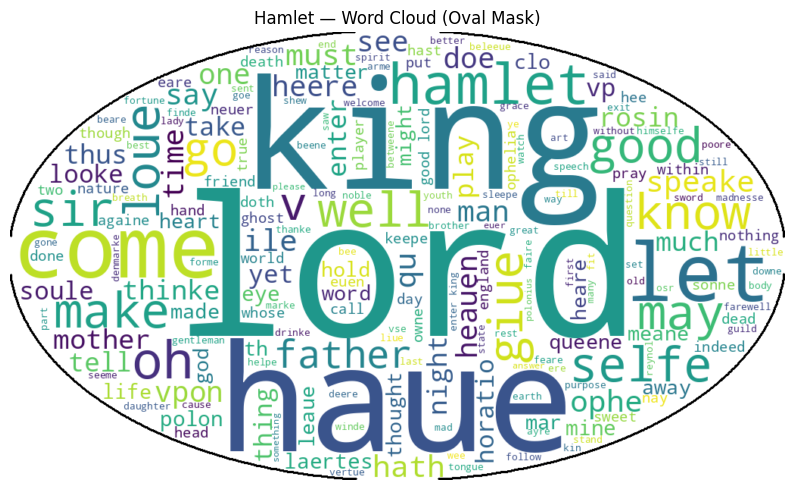

In [11]:
# Cell 11 — Build the word cloud with the oval mask
# WordCloud expects a 2D mask; if the image is RGB/RGBA, convert to 2D via one channel.
if mask_image.ndim == 3:
    mask = mask_image[:, :, 0]
else:
    mask = mask_image

text_for_cloud = " ".join(words)

wc = WordCloud(
    width=1200,
    height=800,
    background_color="white",
    mask=mask,
    contour_width=2
).generate(text_for_cloud)

plt.figure(figsize=(10, 7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Hamlet — Word Cloud (Oval Mask)")
plt.show()

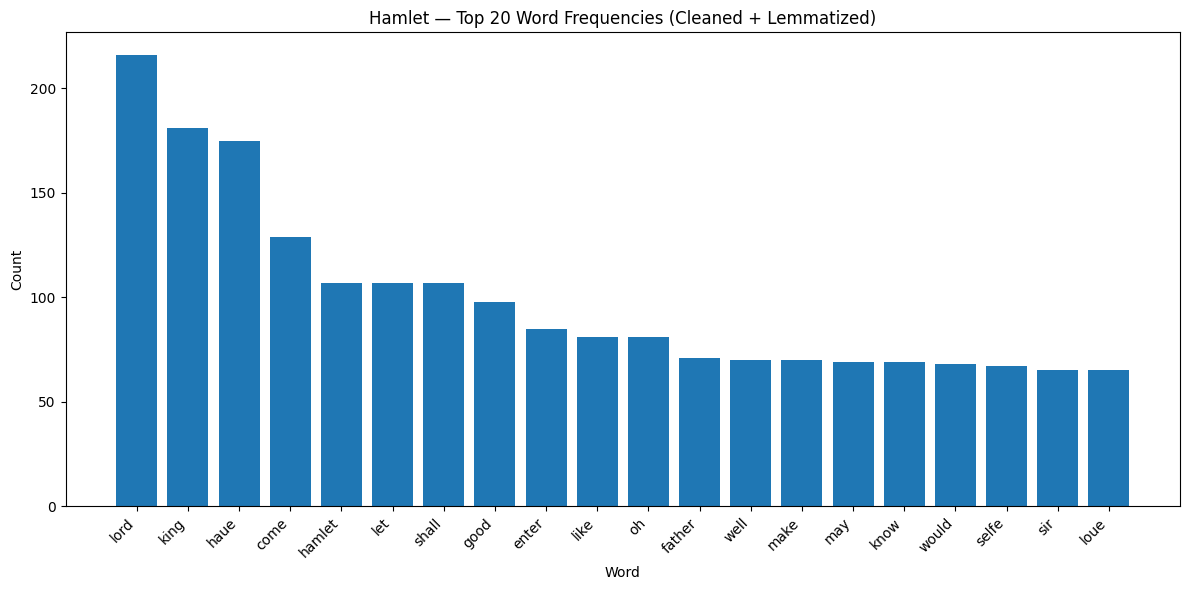

Saved: hamlet_wordcloud.png and hamlet_top20_barchart.png


In [12]:
# Cell 12 — Save outputs
wc.to_file("hamlet_wordcloud.png")

# Save bar chart
plt.figure(figsize=(12, 6))
plt.bar(labels, counts)
plt.xticks(rotation=45, ha="right")
plt.title("Hamlet — Top 20 Word Frequencies (Cleaned + Lemmatized)")
plt.xlabel("Word")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("hamlet_top20_barchart.png", dpi=200)
plt.show()

print("Saved: hamlet_wordcloud.png and hamlet_top20_barchart.png")